In [1]:
import os
import numpy as np

# Path to the CIFAR-10 dataset
DATASET_PATH = "/datasets/cifar/cifar-10-batches-py/"


def unpickle_cifar10_batch(file):
    """
    Load a CIFAR-10 batch file.
    """
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict 


def load_cifar10(path):
    """
    Load the CIFAR-10 dataset from the given path.
    """
    train_data = []
    train_labels = []

    # Load training batches
    for i in range(1, 6):
        batch = unpickle_cifar10_batch(os.path.join(path, f"data_batch_{i}"))
        train_data.append(batch[b"data"])
        train_labels.extend(batch[b"labels"])

    train_data = np.vstack(train_data).reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    train_labels = np.array(train_labels)

    # Load test batch
    test_batch = unpickle_cifar10_batch(os.path.join(path, "test_batch"))
    test_data = test_batch[b"data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    test_labels = np.array(test_batch[b"labels"])

    return train_data, train_labels, test_data, test_labels


# Load the CIFAR-10 dataset
train_images, train_labels, test_images, test_labels = load_cifar10(DATASET_PATH)

# Display dataset shapes
print(f"Train Images: {train_images.shape}, Train Labels: {train_labels.shape}")
print(f"Test Images: {test_images.shape}, Test Labels: {test_labels.shape}")

Train Images: (50000, 32, 32, 3), Train Labels: (50000,)
Test Images: (10000, 32, 32, 3), Test Labels: (10000,)


In [2]:
# CIFAR-10 channel means and standard deviations (computed across the training set)
CHANNEL_MEANS = [0.4914, 0.4822, 0.4465]  # R, G, B means
CHANNEL_STDS = [0.2470, 0.2435, 0.2616]  # R, G, B standard deviations


def normalize_images(images, means, stds):
    """
    Normalize the images using channel-wise mean and standard deviation.
    Args:
        images (numpy.ndarray): The images array of shape (N, H, W, C).
        means (list): List of means for each channel.
        stds (list): List of standard deviations for each channel.
    Returns:
        numpy.ndarray: Normalized images.
    """
    images = images.astype("float32") / 255.0  # Scale pixel values to [0, 1]
    for i in range(3):  # Loop over channels (R, G, B)
        images[..., i] = (images[..., i] - means[i]) / stds[i]
    return images


# Normalize the train and test images
train_images_normalized = normalize_images(train_images, CHANNEL_MEANS, CHANNEL_STDS)
test_images_normalized = normalize_images(test_images, CHANNEL_MEANS, CHANNEL_STDS)

# Verify normalization
print(
    "Train Images Normalized Mean (approx.):",
    train_images_normalized.mean(axis=(0, 1, 2)),
)
print(
    "Train Images Normalized Std (approx.):",
    train_images_normalized.std(axis=(0, 1, 2)),
)

Train Images Normalized Mean (approx.): [-1.2866432e-06 -1.7074010e-04  1.1819301e-04]
Train Images Normalized Std (approx.): [1.000129   0.9999368  0.99995327]


In [3]:
train_images_normalized = train_images_normalized.reshape(
    train_images_normalized.shape[0], -1
)

images0 = train_images_normalized[train_labels == 0]
images1 = train_images_normalized[train_labels == 1]

np.random.shuffle(images0)
np.random.shuffle(images1)
trace = (np.sum(np.var(images0, axis=0)) + np.sum(np.var(images1, axis=0))) / 2
print(f"Trace of covariance (Class 1) = {np.sum(np.var(images0[:3000], axis=0))}")
print(f"Trace of covariance (Class 2) = {np.sum(np.var(images1[:3000], axis=0))}")

Trace of covariance (Class 1) = 2957.030029296875
Trace of covariance (Class 2) = 3373.12548828125


In [9]:
import jax.numpy as jnp
import jax
import numpy as np

from jax import config

config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [10]:
jax.default_backend()

'gpu'

In [11]:
np.random.seed(1)

In [12]:
def generate_gaussian_feature_matrix(n, k, theta):
    return (1 / np.sqrt(n+theta)) * jnp.asarray(np.random.randn(k, n))

In [13]:
def ReLU(z):
    return jnp.maximum(z,0)

def Softplus(z):
    return jnp.log(1 + jnp.exp(z))

In [14]:
def data_generator(m, n, theta, input_label_relation = 1.0, train=True):
    global images0, images1, trace
    if train:
        X0 = jnp.array(images0[:m//2,:])
        X1 = jnp.array(images1[:m//2,:])
    else:
        X0 = jnp.array(images0[2000:2000+m//2,:])
        X1 = jnp.array(images1[2000:2000+m//2,:])

    y0 = - jnp.ones(m // 2) 
    y1 = jnp.ones(m//2)
    X = np.sqrt(theta / trace) * jnp.concatenate((X0, X1), axis=0) + jnp.asarray(np.random.randn(m, n))
    y = jnp.concatenate((y0, y1), axis=0).reshape(-1, 1)
    flip = (np.random.rand(*y.shape) <= (0.5 - input_label_relation / 2))
    y = flip * (-y) + (1 - flip) * y 
    return X, y

In [15]:
def loss(w, y, b, RF, l, lambd):
    return jnp.mean(l(y, RF.T@w + b)) + lambd * (jnp.linalg.norm(w) ** 2)

In [16]:
def l(y, z):
    return ((y-z)**2)

In [17]:
def least_square_estimator(y, b, RF, lambd):
    k, m = RF.shape
    w = jnp.linalg.inv(RF @ RF.T + lambd * m * jnp.eye(k)) @ RF @ (y - b)
    return w

In [18]:
from numpy.polynomial.hermite_e import hermeval

def Hermite(i, x):
    return jnp.asarray(hermeval(np.asarray(x), [0] * i + [1]))

def generate_Hermite_expansion(h, hs, b):
    act_func = lambda x: jnp.asarray(hermeval(np.asarray(x)/b, np.asarray(h))) + hs * jnp.asarray(np.random.randn(*x.shape))
    return act_func

In [19]:
from scipy.special import roots_hermitenorm

nodes, weights = roots_hermitenorm(100)
nodes = jnp.asarray(nodes)
weights = jnp.asarray(weights)

def calculate_expectation(func):
    # Expectation calculation with Gauss-Hermite quadrature
    return jnp.dot(weights, func(nodes)) / np.sqrt(2 * np.pi)

def calculate_h(activation, b):
    h = np.zeros(11)
    hs = np.zeros(11)
    h_var = calculate_expectation(lambda z: activation(b * z) ** 2)
    factorial = 1
    for i in range(11):
        h[i] = calculate_expectation(lambda z: Hermite(i, z) * activation(b * z))
        h_var = h_var - (1 / factorial) * (h[i] ** 2)
        h[i] = h[i] / factorial
        hs[i] = jnp.sqrt(h_var)
        factorial = factorial * (i + 1)
    return h, hs

In [20]:
b = 1
expansion_order = 5
relu_h, relu_hs = calculate_h(ReLU, b)
softplus_h, softplus_hs = calculate_h(Softplus, b)
relu_linear = generate_Hermite_expansion(relu_h[: 2], relu_hs[1], b)
softplus_linear = generate_Hermite_expansion(softplus_h[: 2], softplus_hs[1], b)
relu_poly = generate_Hermite_expansion(relu_h[: expansion_order + 1], relu_hs[expansion_order], b)
softplus_poly = generate_Hermite_expansion(softplus_h[: expansion_order + 1], softplus_hs[expansion_order], b)

In [21]:
n = 3072
k = 3072
m = 4000
m_new = 5000
lambd = 1e-1
delta = 0
theta = trace
NB_TRIALS = 50

In [22]:
import gc,sys

def clear_caches():
    for module_name, module in sys.modules.items():
        if module_name.startswith("jax"):
            if module_name not in ["jax.interpreters.partial_eval"]:
                for obj_name in dir(module):
                    obj = getattr(module, obj_name)
                    if hasattr(obj, "cache_clear"):
                        try:
                            obj.cache_clear()
                        except:
                            pass
    gc.collect()

In [23]:
r_vals = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

relu_l_feature = np.zeros((len(r_vals), NB_TRIALS))
relu_gl_feature = np.zeros((len(r_vals), NB_TRIALS))
relu_l_linear = np.zeros((len(r_vals), NB_TRIALS))
relu_gl_linear = np.zeros((len(r_vals), NB_TRIALS))
relu_l_poly = np.zeros((len(r_vals), NB_TRIALS))
relu_gl_poly = np.zeros((len(r_vals), NB_TRIALS))

softplus_l_feature = np.zeros((len(r_vals), NB_TRIALS))
softplus_gl_feature = np.zeros((len(r_vals), NB_TRIALS))
softplus_l_linear = np.zeros((len(r_vals), NB_TRIALS))
softplus_gl_linear = np.zeros((len(r_vals), NB_TRIALS))
softplus_l_poly = np.zeros((len(r_vals), NB_TRIALS))
softplus_gl_poly = np.zeros((len(r_vals), NB_TRIALS))


def RFM(F, data, data_new, activation, lambd=lambd):
    X, y = data
    X_new, y_new = data_new

    RF_feature = activation(F @ X.T)
    RF_feature_new = activation(F @ X_new.T)
    w_feature = least_square_estimator(y, 0, RF_feature, lambd)
    l_feature_ = loss(w_feature, y, 0, RF_feature, l, lambd)
    gl_feature_ = loss(w_feature, y_new, 0, RF_feature_new, l, 0)

    return (l_feature_.item(), gl_feature_.item())


for e in tqdm(range(NB_TRIALS)):
    for r_i, r in enumerate(tqdm(r_vals)):
        F = generate_gaussian_feature_matrix(n, k, theta)
        data = data_generator(m, n, theta, input_label_relation=r, train=True)
        data_new = data_generator(m, n, theta, input_label_relation=r, train=False)

        (
            relu_l_feature[r_i, e],
            relu_gl_feature[r_i, e],
        ) = RFM(
            F,
            data,
            data_new,
            ReLU,
            lambd=lambd
        )
        (
            relu_l_linear[r_i, e], 
            relu_gl_linear[r_i, e]
        ) = RFM(
            F,
            data,
            data_new,
            relu_linear,
            lambd=lambd
        )
        (
            relu_l_poly[r_i, e], 
            relu_gl_poly[r_i, e]
        ) = RFM(
            F,
            data,
            data_new,
            relu_poly,
            lambd=lambd
        )

        (
            softplus_l_feature[r_i, e],
            softplus_gl_feature[r_i, e],
        ) = RFM(
            F,
            data,
            data_new,
            Softplus,
            lambd=lambd
        )

        (
            softplus_l_linear[r_i, e],
            softplus_gl_linear[r_i, e]
        ) = RFM(
            F,
            data,
            data_new,
            softplus_linear,
            lambd=lambd
        )

        (
            softplus_l_poly[r_i, e], 
            softplus_gl_poly[r_i, e]
        ) = RFM(
            F,
            data,
            data_new,
            softplus_poly,
            lambd=lambd
        )

        clear_caches()

In [24]:
import matplotlib as mpl

mpl.rcParams.update(mpl.rcParamsDefault)

plt.style.use(["science", "bright"])
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times"],
        "font.size": 10,
        "figure.dpi": "600",
    }
)

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

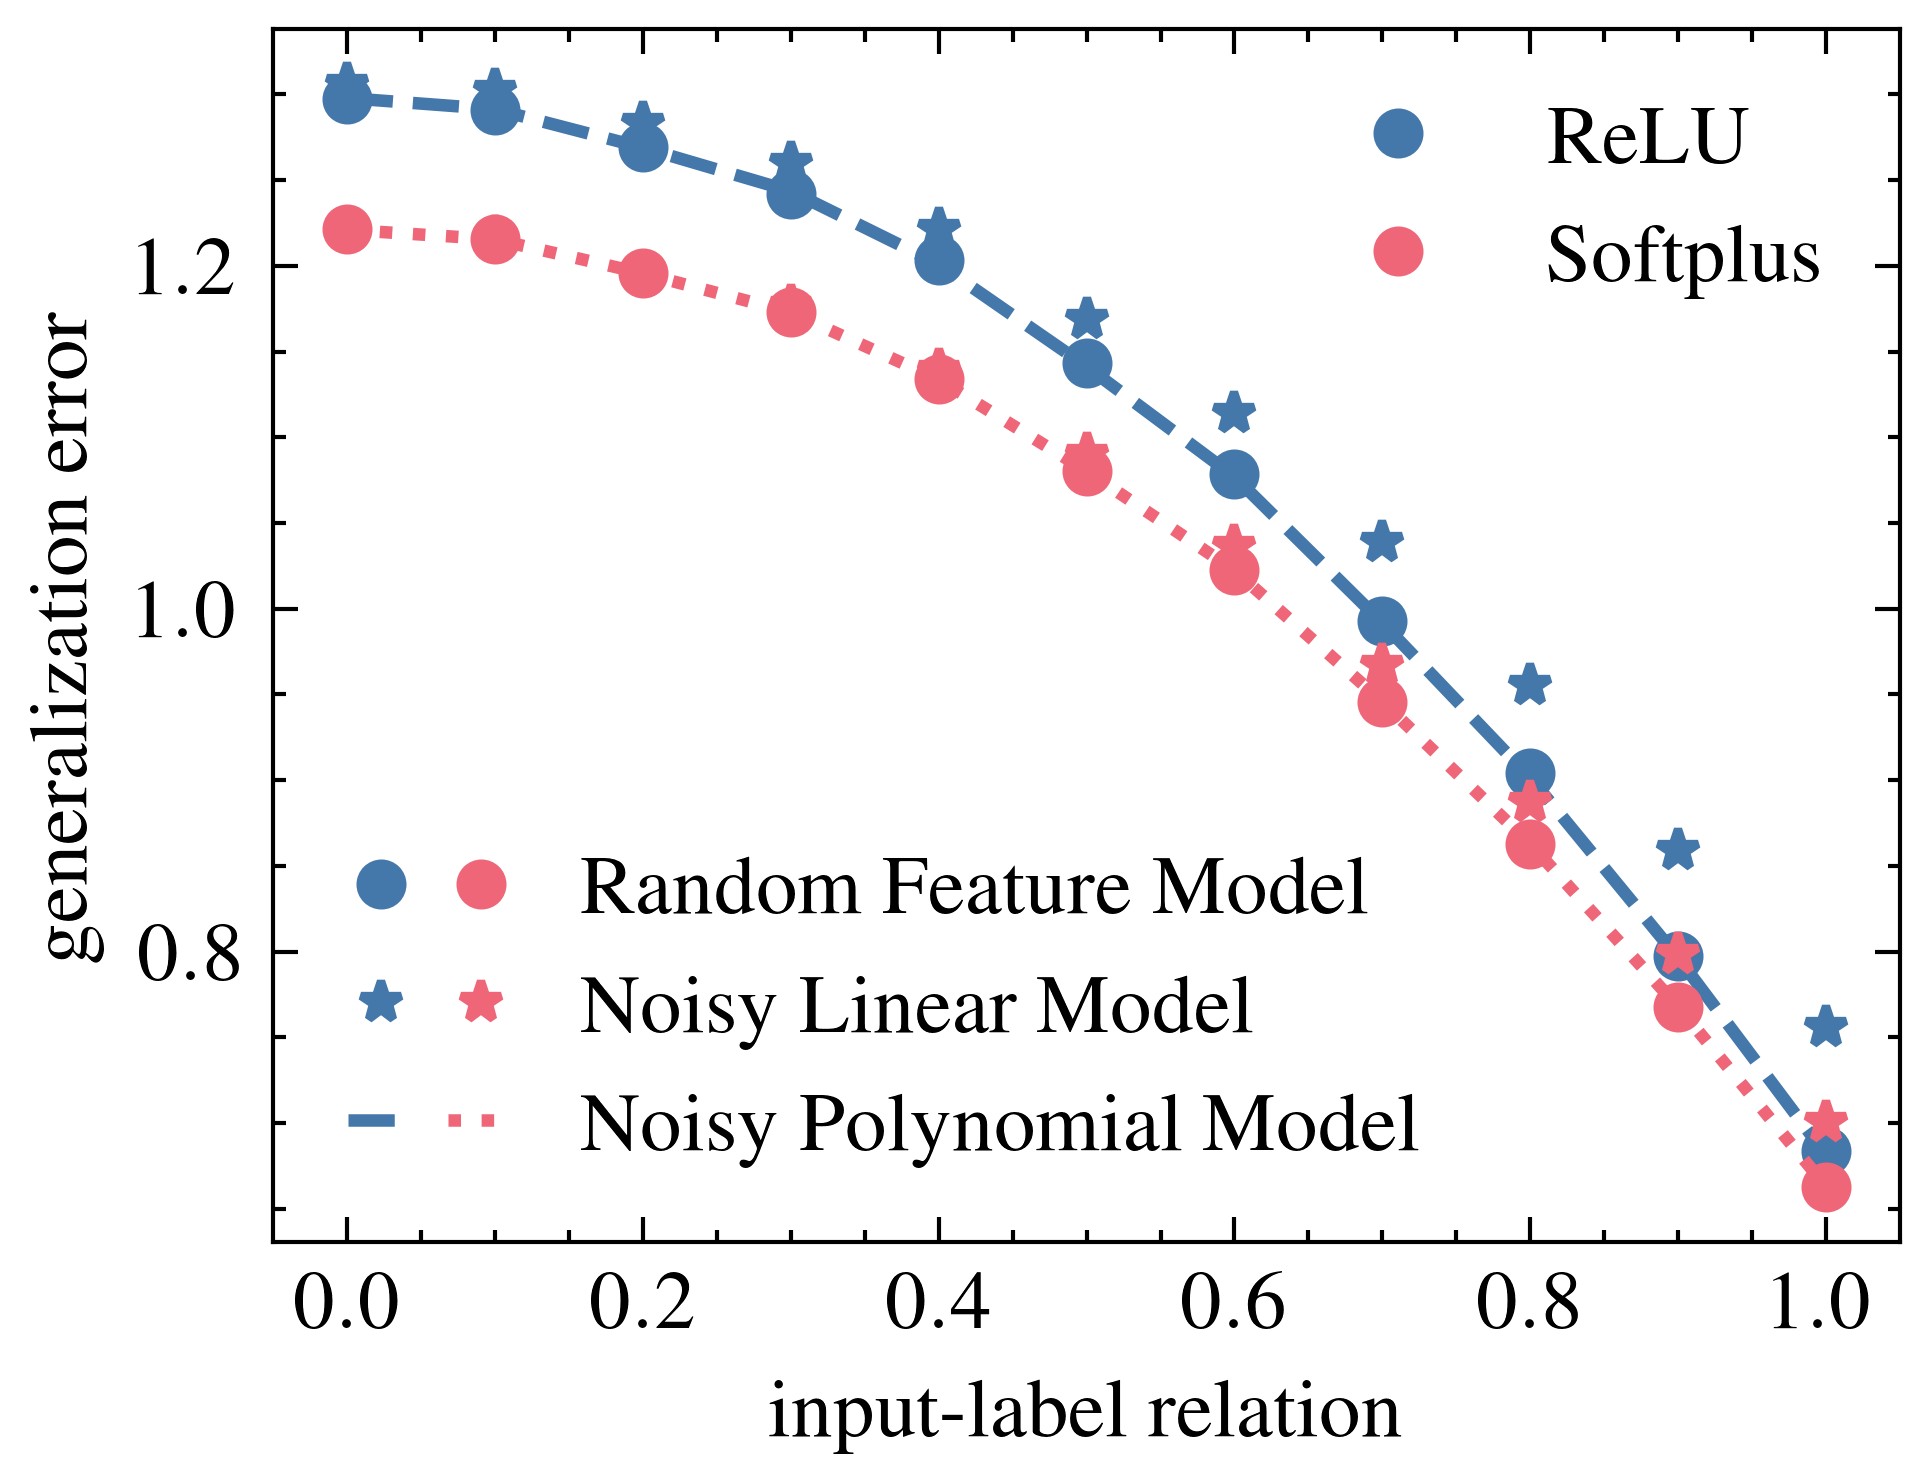

In [25]:
from matplotlib.legend_handler import HandlerTuple

plt.figure()
(relu_feature_gen,) = plt.plot(
    r_vals,
    np.mean(relu_gl_feature, axis=1),
    color=colors[0],
    linestyle="None",
    marker="o",
    markersize=5,
)
(relu_gaussian_gen,) = plt.plot(
    r_vals,
    np.mean(relu_gl_linear, axis=1),
    color=colors[0],
    linestyle="None",
    marker="*",
    markersize=5,
)

(relu_gaussian_gen3,) = plt.plot(
    r_vals,
    np.mean(relu_gl_poly, axis=1),
    color=colors[0],
    linestyle="dashed",
    linewidth=1.5,
    label="ReLU",
)

(softplus_feature_gen,) = plt.plot(
    r_vals,
    np.mean(softplus_gl_feature, axis=1),
    color=colors[1],
    linestyle="None",
    marker="o",
    markersize=5,
)
(softplus_gaussian_gen,) = plt.plot(
    r_vals,
    np.mean(softplus_gl_linear, axis=1),
    color=colors[1],
    linestyle="None",
    marker="*",
    markersize=5,
)
(softplus_gaussian_gen3,) = plt.plot(
    r_vals,
    np.mean(softplus_gl_poly, axis=1),
    color=colors[1],
    linestyle="dotted",
    linewidth=1.5,
    label="Softplus",
)
plt.xlabel(r"input-label relation")
plt.ylabel(r"generalization error")

legend1 = plt.legend(
    [(relu_feature_gen), (softplus_feature_gen)],
    ["ReLU", "Softplus"],
    loc=1,
    handler_map={tuple: HandlerTuple(ndivide=None)},
)
legend2 = plt.legend(
    [
        (relu_feature_gen, softplus_feature_gen),
        (relu_gaussian_gen, softplus_gaussian_gen),
        (relu_gaussian_gen3, softplus_gaussian_gen3),
    ],
    [
        "Random Feature Model",
        "Noisy Linear Model",
        "Noisy Polynomial Model",
    ],
    loc=3,
    handler_map={tuple: HandlerTuple(ndivide=None)},
)
plt.gca().add_artist(legend1)

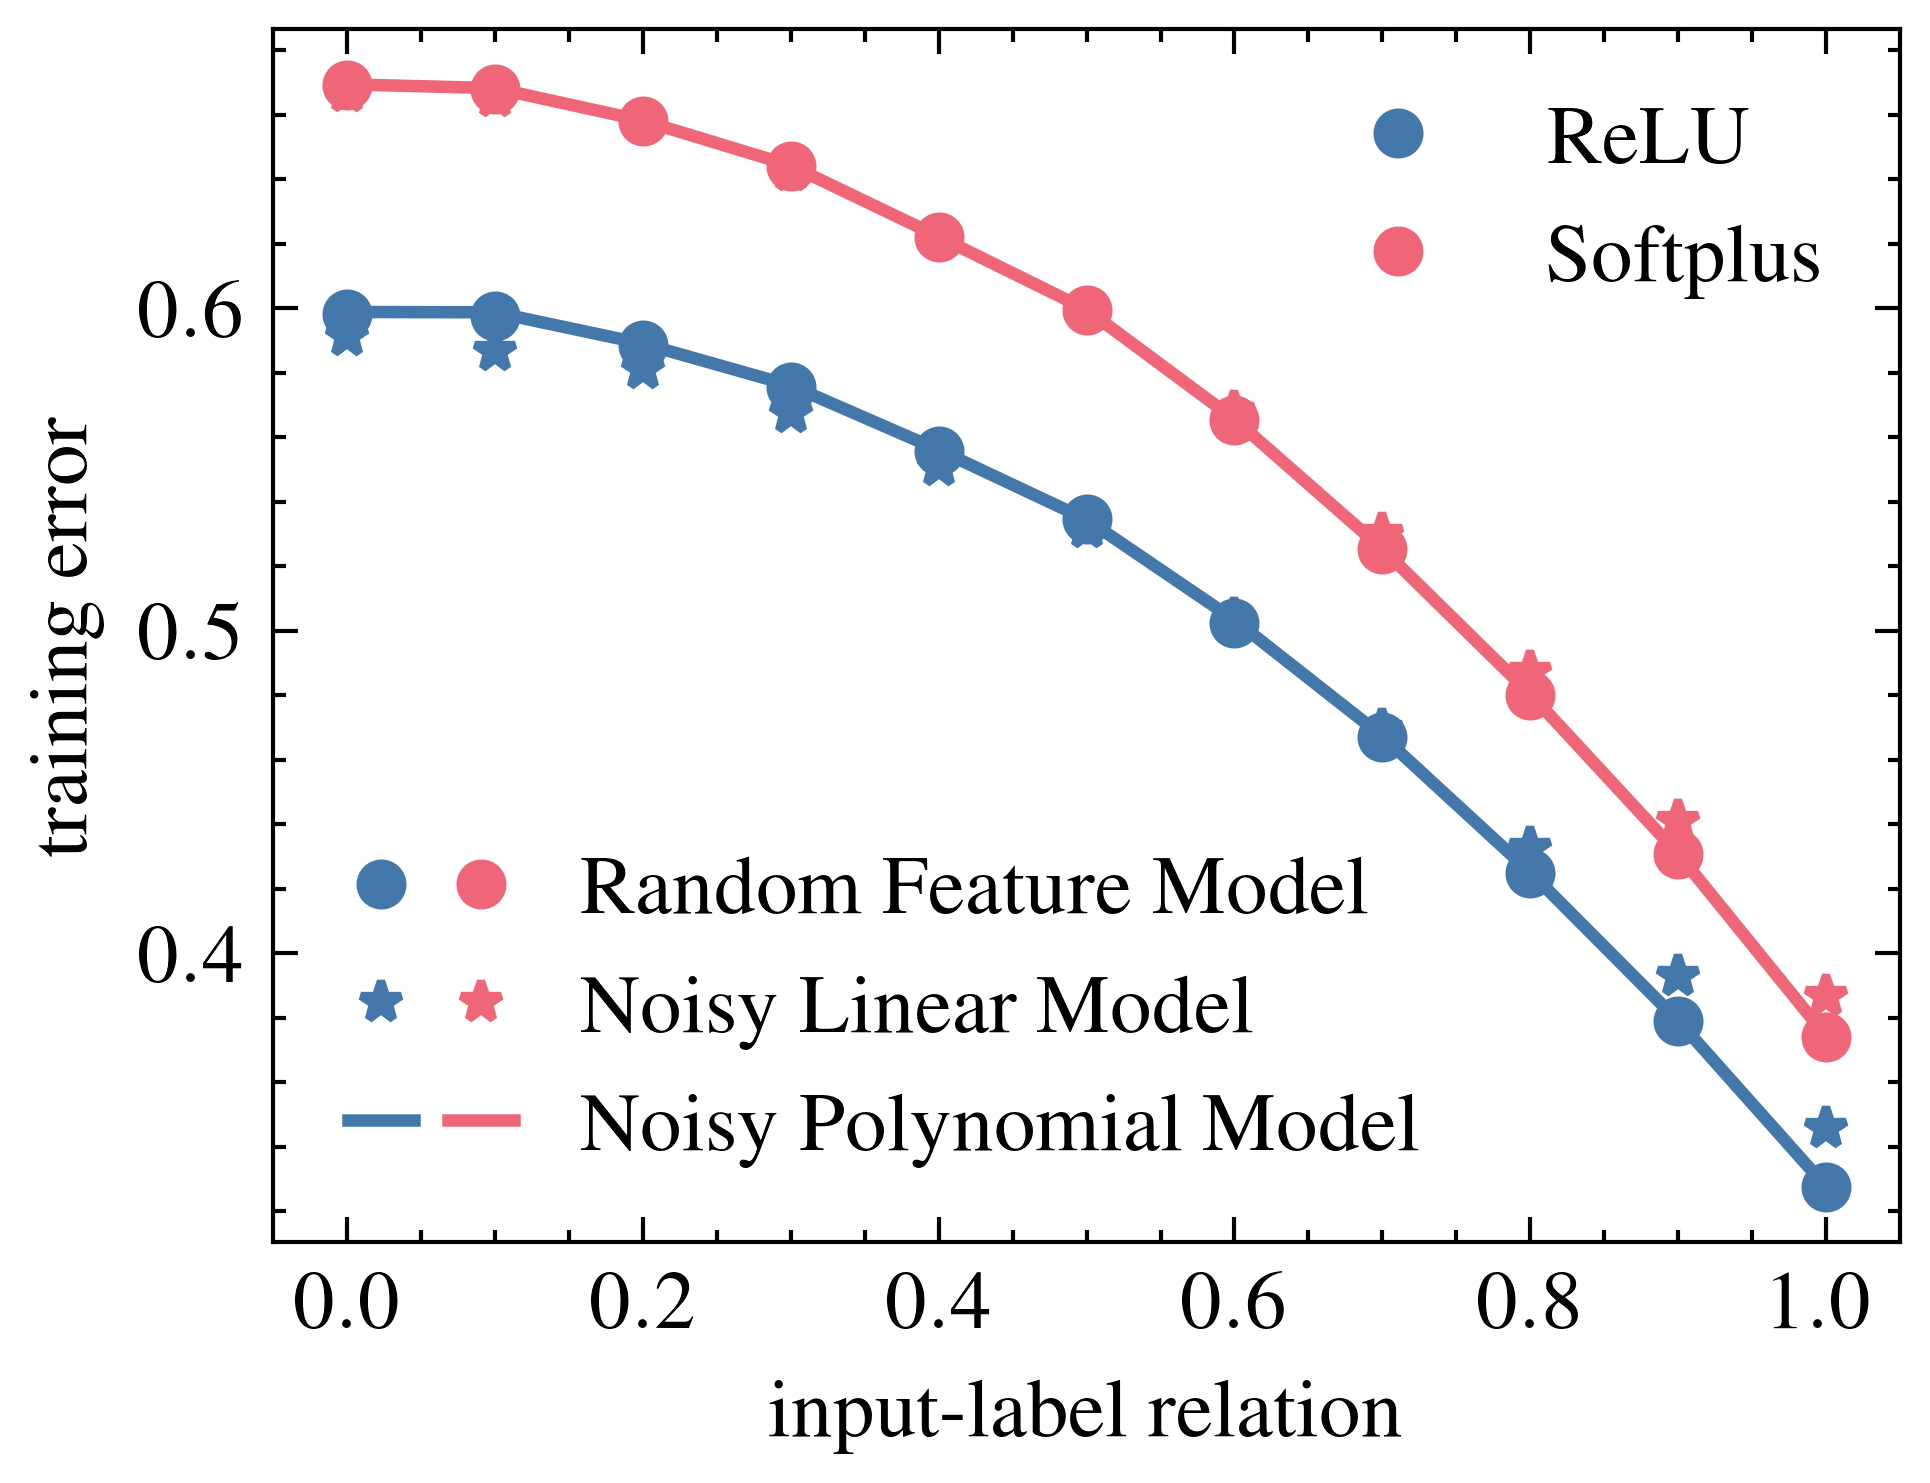

In [26]:
from matplotlib.legend_handler import HandlerTuple

plt.figure()
(relu_feature,) = plt.plot(
    r_vals,
    np.mean(relu_l_feature, axis=1),
    color=colors[0],
    linestyle="None",
    marker="o",
    markersize=5,
)
(relu_gaussian,) = plt.plot(
    r_vals,
    np.mean(relu_l_linear, axis=1),
    color=colors[0],
    linestyle="None",
    marker="*",
    markersize=5,
)
(relu_gaussian3,) = plt.plot(
    r_vals,
    np.mean(relu_l_poly, axis=1),
    color=colors[0],
    linewidth=1.5,
    linestyle="solid",
)

(softplus_feature,) = plt.plot(
    r_vals,
    np.mean(softplus_l_feature, axis=1),
    color=colors[1],
    linestyle="None",
    marker="o",
    markersize=5,
)
(softplus_gaussian,) = plt.plot(
    r_vals,
    np.mean(softplus_l_linear, axis=1),
    color=colors[1],
    linestyle="None",
    marker="*",
    markersize=5,
)
(softplus_gaussian3,) = plt.plot(
    r_vals,
    np.mean(softplus_l_poly, axis=1),
    color=colors[1],
    linewidth=1.5,
    linestyle="solid",
)

plt.xlabel(r"input-label relation")
plt.ylabel(r"training error")
#plt.ylim(0.15, 0.35)

legend1 = plt.legend(
    [(relu_feature), (softplus_feature)],
    ["ReLU", "Softplus"],
    loc=1,
    handler_map={tuple: HandlerTuple(ndivide=None)},
)
legend2 = plt.legend(
    [
        (relu_feature, softplus_feature),
        (relu_gaussian, softplus_gaussian),
        (relu_gaussian3, softplus_gaussian3),
    ],
    [
        "Random Feature Model",
        "Noisy Linear Model",
        "Noisy Polynomial Model",
    ],
    loc=3,
    handler_map={tuple: HandlerTuple(ndivide=None)},
)
plt.gca().add_artist(legend1)

In [27]:
input_label_correlation = np.zeros((len(r_vals), NB_TRIALS))

for e in tqdm(range(NB_TRIALS)):
    for r_i, r in enumerate(tqdm(r_vals)):
        data = data_generator(m, n, theta, input_label_relation=r, train=True)
        X, y = data
        X = (X - X.mean(axis=0, keepdims=True)) / (X.std(axis=0, keepdims=True) + 1e-8)
        y = (y - y.mean(axis=0, keepdims=True)) / (y.std(axis=0, keepdims=True) + 1e-8)
        input_label_correlation[r_i, e] = np.linalg.norm(X.T @ y / m)

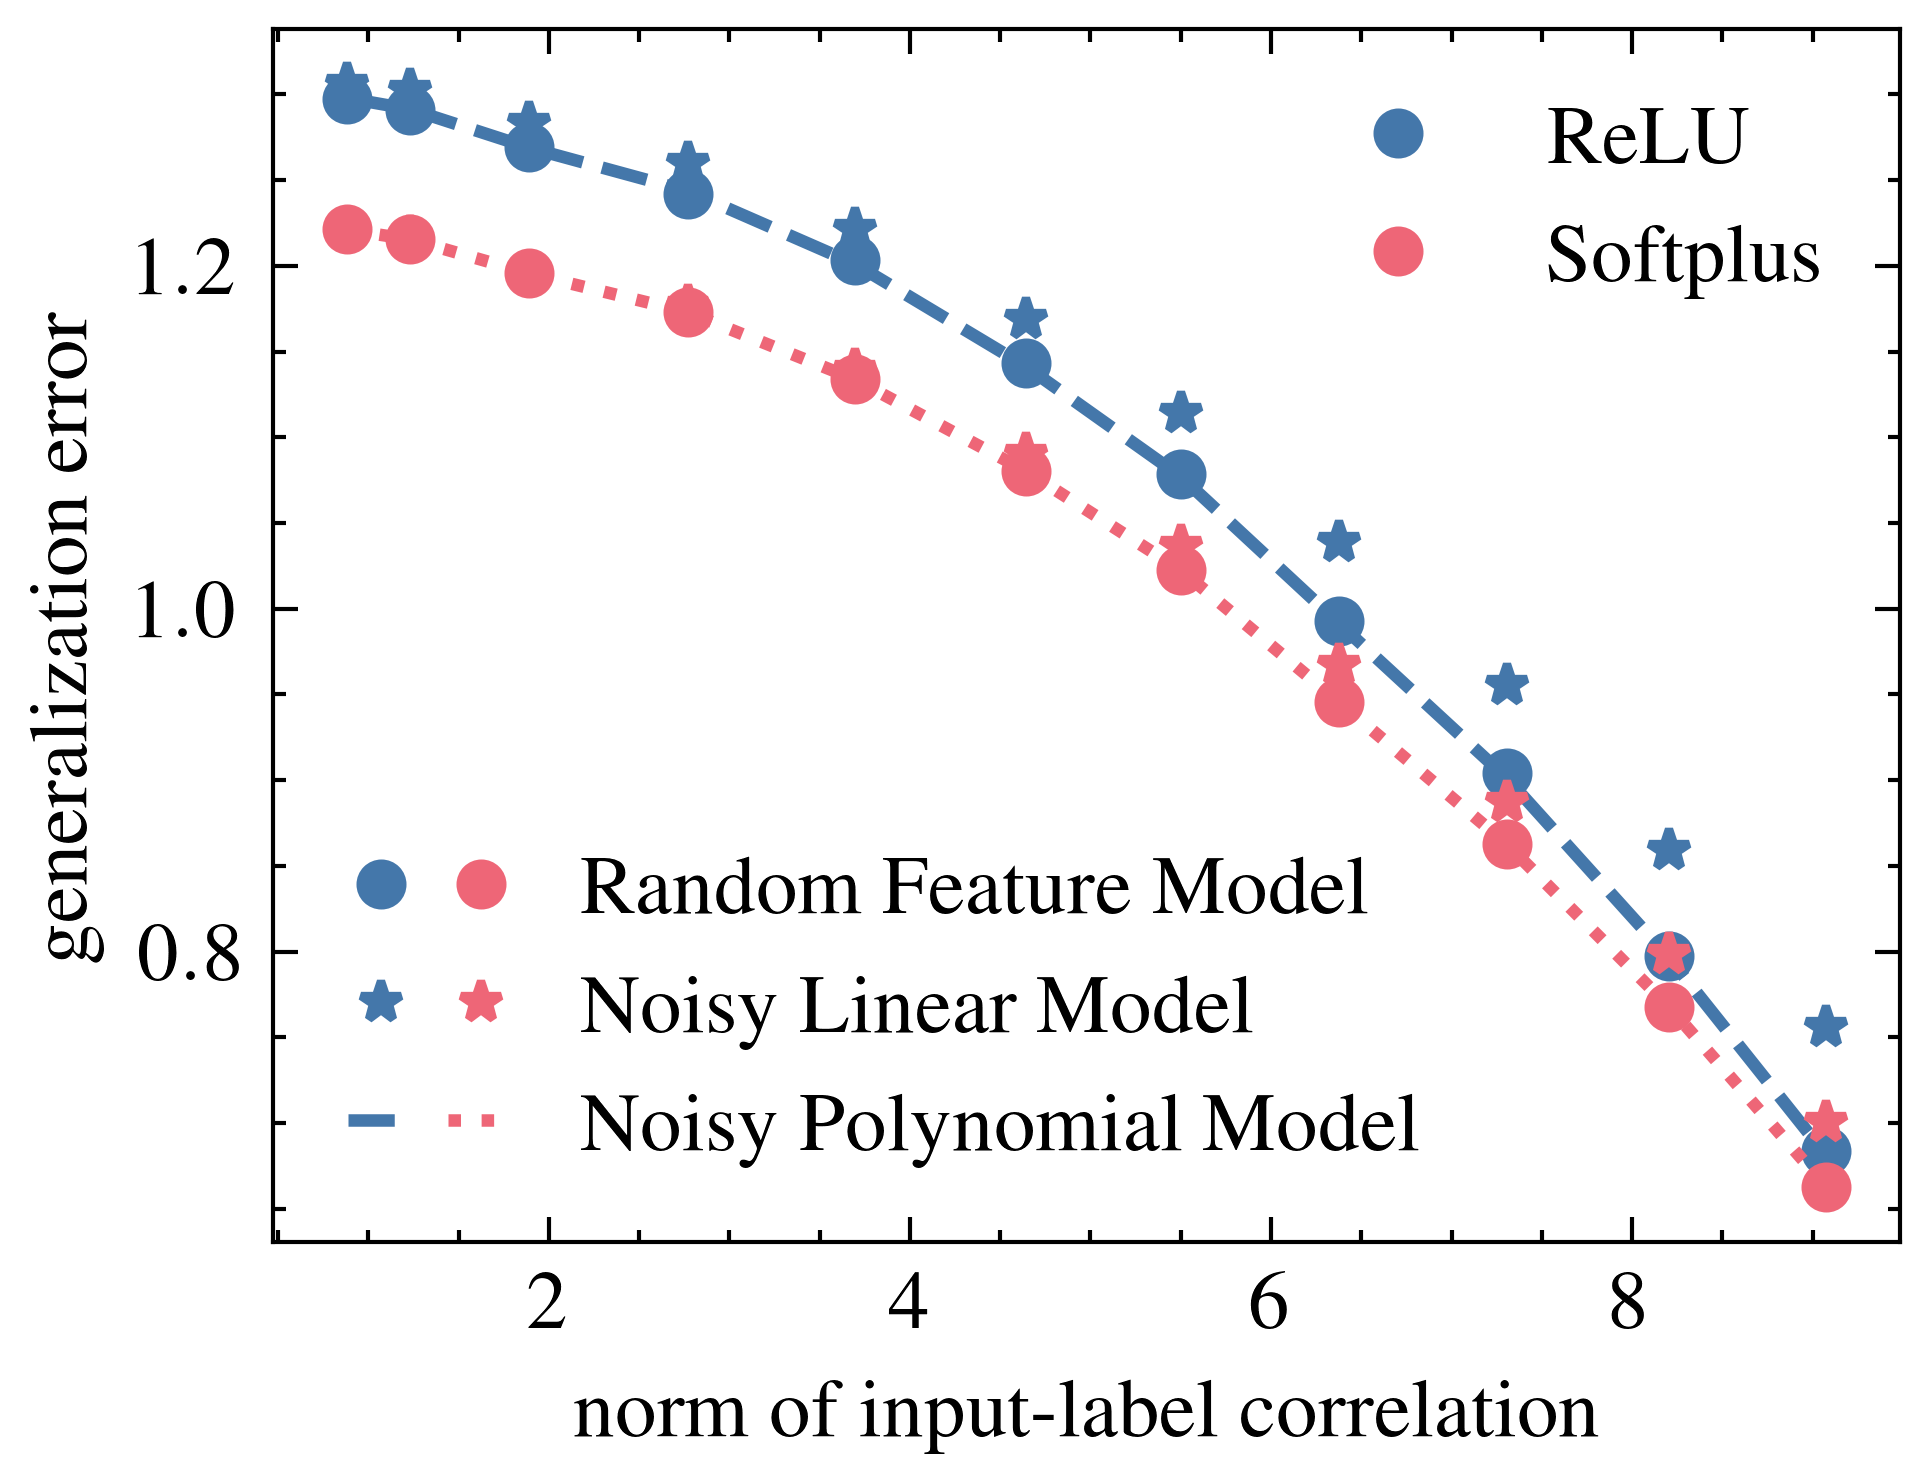

In [29]:
from matplotlib.legend_handler import HandlerTuple

plt.figure()
(relu_feature_gen,) = plt.plot(
    np.mean(input_label_correlation, axis=1),
    np.mean(relu_gl_feature, axis=1),
    color=colors[0],
    linestyle="None",
    marker="o",
    markersize=5,
)
(relu_gaussian_gen,) = plt.plot(
    np.mean(input_label_correlation, axis=1),
    np.mean(relu_gl_linear, axis=1),
    color=colors[0],
    linestyle="None",
    marker="*",
    markersize=5,
)

(relu_gaussian_gen3,) = plt.plot(
    np.mean(input_label_correlation, axis=1),
    np.mean(relu_gl_poly, axis=1),
    color=colors[0],
    linestyle="dashed",
    linewidth=1.5,
    label="ReLU",
)

(softplus_feature_gen,) = plt.plot(
    np.mean(input_label_correlation, axis=1),
    np.mean(softplus_gl_feature, axis=1),
    color=colors[1],
    linestyle="None",
    marker="o",
    markersize=5,
)
(softplus_gaussian_gen,) = plt.plot(
    np.mean(input_label_correlation, axis=1),
    np.mean(softplus_gl_linear, axis=1),
    color=colors[1],
    linestyle="None",
    marker="*",
    markersize=5,
)
(softplus_gaussian_gen3,) = plt.plot(
    np.mean(input_label_correlation, axis=1),
    np.mean(softplus_gl_poly, axis=1),
    color=colors[1],
    linestyle="dotted",
    linewidth=1.5,
    label="Softplus",
)
plt.xlabel(r"norm of input-label correlation")
plt.ylabel(r"generalization error")

legend1 = plt.legend(
    [(relu_feature_gen), (softplus_feature_gen)],
    ["ReLU", "Softplus"],
    loc=1,
    handler_map={tuple: HandlerTuple(ndivide=None)},
)
legend2 = plt.legend(
    [
        (relu_feature_gen, softplus_feature_gen),
        (relu_gaussian_gen, softplus_gaussian_gen),
        (relu_gaussian_gen3, softplus_gaussian_gen3),
    ],
    [
        "Random Feature Model",
        "Noisy Linear Model",
        "Noisy Polynomial Model",
    ],
    loc=3,
    handler_map={tuple: HandlerTuple(ndivide=None)},
)
plt.gca().add_artist(legend1)

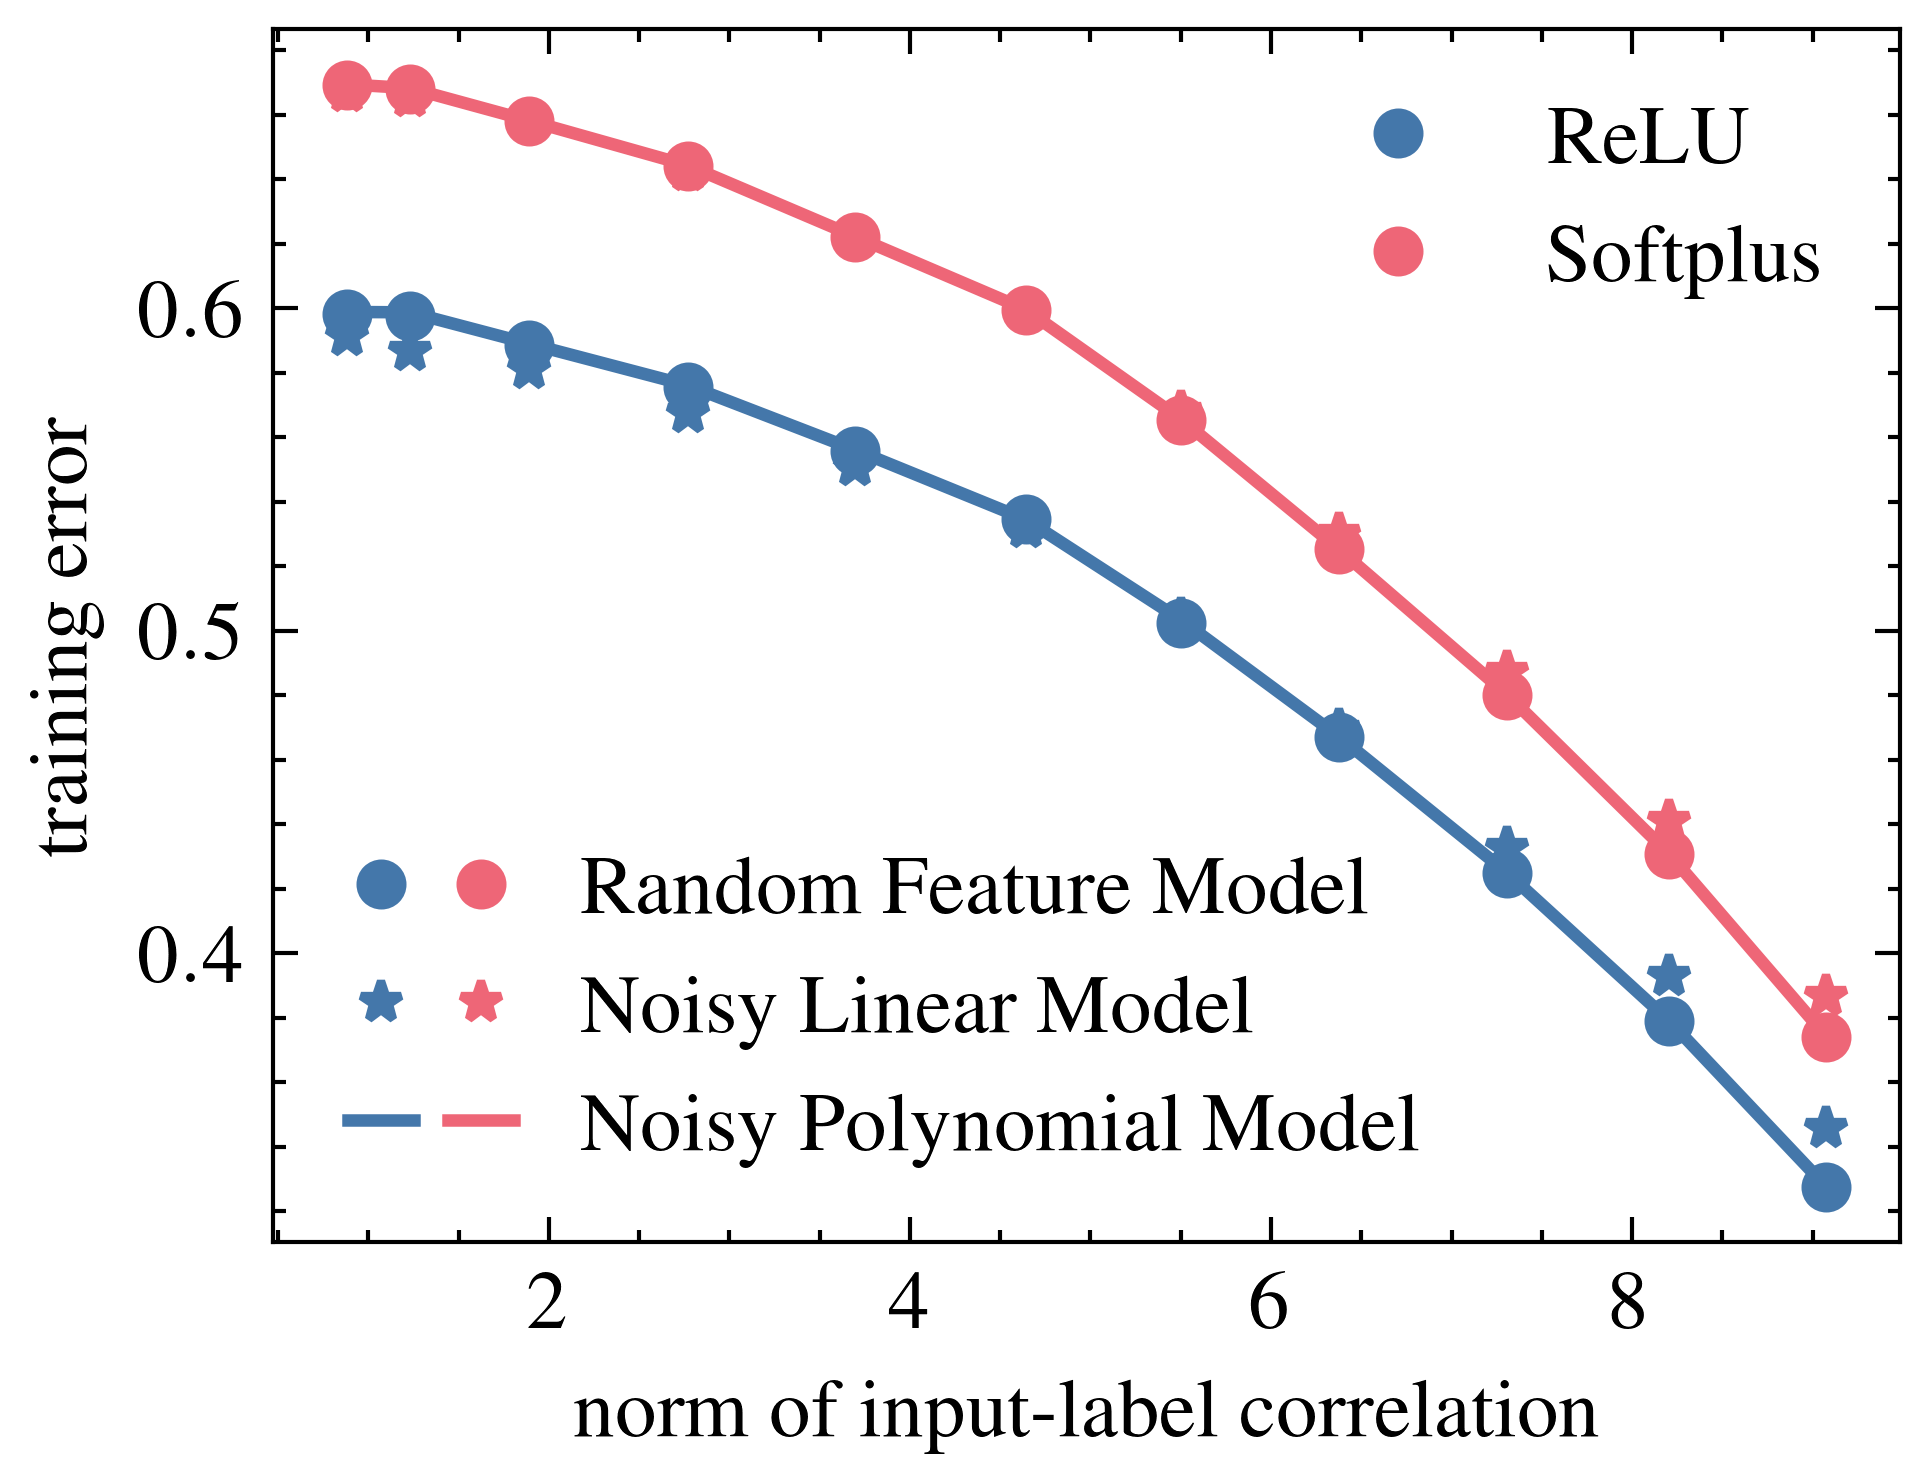

In [31]:
from matplotlib.legend_handler import HandlerTuple

plt.figure()
(relu_feature,) = plt.plot(
    np.mean(input_label_correlation, axis=1),
    np.mean(relu_l_feature, axis=1),
    color=colors[0],
    linestyle="None",
    marker="o",
    markersize=5,
)
(relu_gaussian,) = plt.plot(
    np.mean(input_label_correlation, axis=1),
    np.mean(relu_l_linear, axis=1),
    color=colors[0],
    linestyle="None",
    marker="*",
    markersize=5,
)
(relu_gaussian3,) = plt.plot(
    np.mean(input_label_correlation, axis=1),
    np.mean(relu_l_poly, axis=1),
    color=colors[0],
    linewidth=1.5,
    linestyle="solid",
)

(softplus_feature,) = plt.plot(
    np.mean(input_label_correlation, axis=1),
    np.mean(softplus_l_feature, axis=1),
    color=colors[1],
    linestyle="None",
    marker="o",
    markersize=5,
)
(softplus_gaussian,) = plt.plot(
    np.mean(input_label_correlation, axis=1),
    np.mean(softplus_l_linear, axis=1),
    color=colors[1],
    linestyle="None",
    marker="*",
    markersize=5,
)
(softplus_gaussian3,) = plt.plot(
    np.mean(input_label_correlation, axis=1),
    np.mean(softplus_l_poly, axis=1),
    color=colors[1],
    linewidth=1.5,
    linestyle="solid",
)

plt.xlabel(r"norm of input-label correlation")
plt.ylabel(r"training error")
# plt.ylim(0.15, 0.35)

legend1 = plt.legend(
    [(relu_feature), (softplus_feature)],
    ["ReLU", "Softplus"],
    loc=1,
    handler_map={tuple: HandlerTuple(ndivide=None)},
)
legend2 = plt.legend(
    [
        (relu_feature, softplus_feature),
        (relu_gaussian, softplus_gaussian),
        (relu_gaussian3, softplus_gaussian3),
    ],
    [
        "Random Feature Model",
        "Noisy Linear Model",
        "Noisy Polynomial Model",
    ],
    loc=3,
    handler_map={tuple: HandlerTuple(ndivide=None)},
)
plt.gca().add_artist(legend1)